In [1]:
import sys
import os
import pandas as pd
import numpy as np

from src.data_loader import load_data
from src.solver_LAM import solve_lam_stqp
from src.solver_Markowitz import solve_markowitz
from src.visualize_portfolio import visualize_portfolio_performance
from src.efficient_frontier import compute_efficient_frontier, plot_efficient_frontier


## **パラメータ設定**

In [2]:
# Parameters
DATA_FILE = 'data/topix-large500.csv'
TARGET_RETURN = 0.0005  # 0.05% daily return (approx 12% annual)
CARDINALITY_K = 10      # Max 10 assets
MIN_WEIGHT = 0.01       # Min 1% per asset
MAX_WEIGHT = 1.0        # Max 100% per asset
PENALTY_M = 1000.0      # Penalty for return deviation

print("=== Portfolio Optimization (LAM/StQP) ===")
print(f"Target Return: {TARGET_RETURN:.6f}")
print(f"Cardinality K: {CARDINALITY_K}")
print(f"Penalty M: {PENALTY_M}")

=== Portfolio Optimization (LAM/StQP) ===
Target Return: 0.000500
Cardinality K: 10
Penalty M: 1000.0


## **データの読み込み**

In [3]:
# 1. Load Data
mu, sigma, assets, df = load_data(DATA_FILE)
print(mu)
print()
print(sigma)
print()
print(assets)
print()
df.head()

Loading data from data/topix-large500.csv...
Data loaded successfully. 495 assets.
Optimization period: 2021-10-21 to 2025-11-18 (998 periods)
2914    0.001000
3382    0.000428
4063    0.000377
4502    0.000367
4568    0.000528
          ...   
9861    0.000402
9934    0.000628
9962   -0.000460
9987    0.000717
9989    0.000298
Length: 495, dtype: float64

          2914      3382      4063      4502      4568      6098      6367  \
2914  0.000174  0.000075  0.000098  0.000057  0.000099  0.000086  0.000089   
3382  0.000075  0.000364  0.000096  0.000062  0.000090  0.000094  0.000093   
4063  0.000098  0.000096  0.000413  0.000076  0.000175  0.000281  0.000201   
4502  0.000057  0.000062  0.000076  0.000136  0.000127  0.000084  0.000066   
4568  0.000099  0.000090  0.000175  0.000127  0.000593  0.000188  0.000154   
...        ...       ...       ...       ...       ...       ...       ...   
9861  0.000038  0.000055  0.000050  0.000030  0.000041  0.000056  0.000043   
9934  0.000080  0

,2914,3382,4063,4502,4568,6098,6367,6501,6503,6758,...,9719,9744,9759,9766,9831,9861,9934,9962,9987,9989
Date,,,,,,,,,,,,,,,,,,,,,
2021-10-20,2295.5,1588.3333,3902.0,3246.0,2760.0,7232.0,25730.0,1366.0,1606.5,2564.0,...,2349.0,2183.3333,2001.0,6650.0,462.0,2219.0,2721.0,4840.0,3290.0,3510.0
2021-10-21,2271.5,1591.0000,3829.0,3207.0,2734.0,7045.0,25415.0,1338.4,1587.5,2533.0,...,2321.0,2163.3333,2001.0,6400.0,458.0,2172.0,2686.0,4775.0,3215.0,3515.0
2021-10-22,2251.0,1581.6666,3825.0,3203.0,2750.5,7015.0,25580.0,1337.0,1583.5,2563.0,...,2320.0,2200.0000,2028.0,6540.0,455.0,2157.0,2707.0,4795.0,3225.0,3445.0
2021-10-25,2232.0,1575.6666,3817.0,3187.0,2739.5,7223.0,25275.0,1346.4,1586.0,2613.0,...,2311.0,2213.3333,2024.0,6460.0,446.0,2156.0,2717.0,4780.0,3175.0,3370.0
2021-10-26,2253.5,1599.3333,3896.0,3184.0,2855.0,7400.0,25595.0,1355.0,1603.5,2682.0,...,2301.0,2230.0000,2050.0,6630.0,448.0,2163.0,2734.0,4825.0,3170.0,3420.0


## **最適化問題の求解**

### **LAMモデル**

In [4]:
# 2. Solve
result_LAM = solve_lam_stqp(
    mu, sigma, 
    target_return=TARGET_RETURN,
    k_max=CARDINALITY_K,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT,
    penalty_m=PENALTY_M
)

# 3. Output Results
print("\n=== Optimization Results ===")
print(f"Objective Value: {result_LAM['objective']:.6f}")
print(f"Portfolio Return: {result_LAM['return']:.6f}")
print(f"Portfolio Risk (Std): {result_LAM['risk']:.6f}")
print(f"Number of Assets: {len(result_LAM['assets'])}")
print("\nSelected Assets and Weights:")
print(result_LAM['weights'].sort_values(ascending=False))

# Save to CSV
result_LAM['weights'].to_csv('output/optimization_result_LAM.csv', header=['Weight'])
print("\nResults saved to optimization_result_LAM.csv")

Starting optimization with K=10, Target=0.0005, M=1000.0
  Step k=1/10...
    New best found at k=1: Obj=0.000102
  Step k=2/10...
    New best found at k=2: Obj=0.000070
  Step k=3/10...
    New best found at k=3: Obj=0.000065
  Step k=4/10...
    New best found at k=4: Obj=0.000065
  Step k=5/10...
    New best found at k=5: Obj=0.000039
  Step k=6/10...
    New best found at k=6: Obj=0.000035
  Step k=7/10...
    New best found at k=7: Obj=0.000033
  Step k=8/10...
    New best found at k=8: Obj=0.000031
  Step k=9/10...
    New best found at k=9: Obj=0.000030
  Step k=10/10...
    New best found at k=10: Obj=0.000030

=== Optimization Results ===
Objective Value: 0.000030
Portfolio Return: 0.000485
Portfolio Risk (Std): 0.005415
Number of Assets: 10

Selected Assets and Weights:
8729    0.200122
9023    0.192204
9434    0.144868
4665    0.144446
5016    0.108394
8267    0.078606
9072    0.074208
5838    0.023508
6417    0.023268
5803    0.010375
dtype: float64

Results saved to opt

### **Markowitzモデル**

In [5]:
# 2. Solve
result_Markowitz = solve_markowitz(
    mu, sigma, 
    target_return=TARGET_RETURN,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT
)

# 3. Output Results
print("\n=== Optimization Results ===")
print(f"Objective Value: {result_Markowitz['objective']:.6f}")
print(f"Portfolio Return: {result_Markowitz['return']:.6f}")
print(f"Portfolio Risk (Std): {result_Markowitz['risk']:.6f}")
print(f"Number of Assets: {len(result_Markowitz['assets'])}")
print("\nSelected Assets and Weights:")
print(result_Markowitz['weights'].sort_values(ascending=False))

# Save to CSV
result_Markowitz['weights'].to_csv('output/optimization_result_Markowitz.csv', header=['Weight'])
print("\nResults saved to optimization_result_Markowitz.csv")


=== Optimization Results ===
Objective Value: 0.002814
Portfolio Return: 0.002831
Portfolio Risk (Std): 0.053049
Number of Assets: 495

Selected Assets and Weights:
2914    0.01
3382    0.01
4063    0.01
4502    0.01
4568    0.01
        ... 
9861    0.01
9934    0.01
9962    0.01
9987    0.01
9989    0.01
Length: 495, dtype: float64

Results saved to optimization_result_Markowitz.csv


## **最適ポートフォリオのパフォーマンス可視化**

### **LAMモデル**

=== Portfolio Performance Visualization ===
Optimization Period: 2022-01-01 to 2022-12-31
Loaded 10 selected assets.
Loading data from c:\Users\Soichiro\Documents\研究室\03_修士研究\00_授業\秋学期\火3_AFE02\中間発表\AFE02_student_presentation\data\topix-large500.csv...
Data loaded successfully. 495 assets.
Optimization period: 2022-01-04 to 2022-12-30 (244 periods)
Saved figure to: image\portfolio_performance_LAM.png


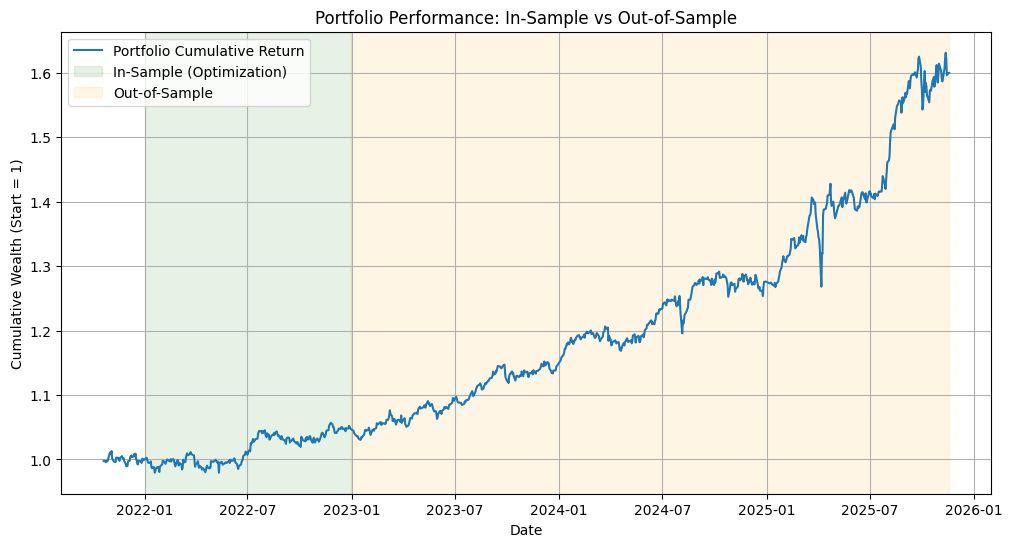

In [6]:
visualize_portfolio_performance(
    start_date = '2022-01-01',
    end_date = '2022-12-31',
    weight_csv_path = 'output/optimization_result_LAM.csv',
    output_dir="image",
    output_filename="portfolio_performance_LAM.png"
)

### **Markowitzモデル**

=== Portfolio Performance Visualization ===
Optimization Period: 2022-01-01 to 2022-12-31
Loaded 495 selected assets.
Loading data from c:\Users\Soichiro\Documents\研究室\03_修士研究\00_授業\秋学期\火3_AFE02\中間発表\AFE02_student_presentation\data\topix-large500.csv...
Data loaded successfully. 495 assets.
Optimization period: 2022-01-04 to 2022-12-30 (244 periods)
Saved figure to: image\portfolio_performance_Markowitz.png


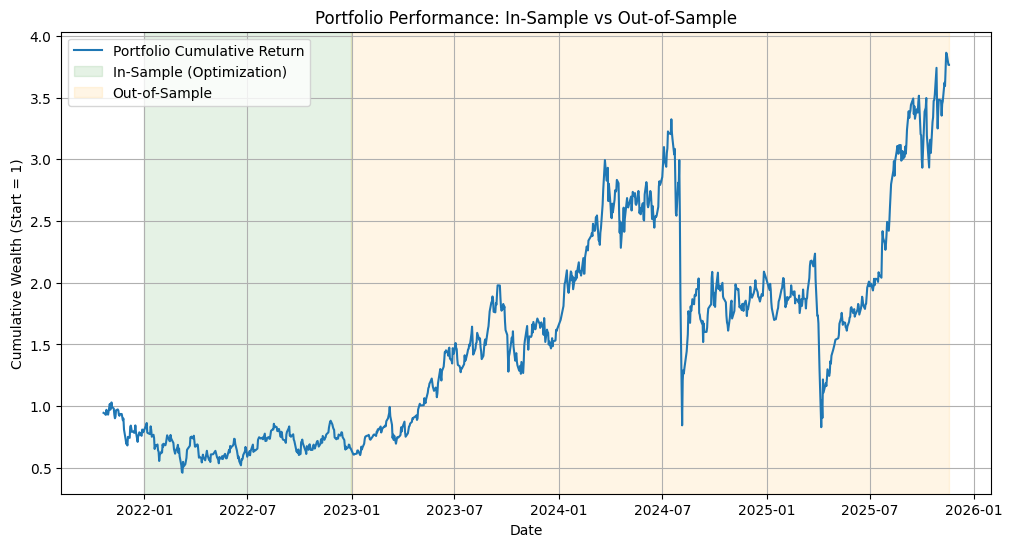

In [7]:
visualize_portfolio_performance(
    start_date = '2022-01-01',
    end_date = '2022-12-31',
    weight_csv_path = 'output/optimization_result_Markowitz.csv',
    output_dir="image",
    output_filename="portfolio_performance_Markowitz.png"
)

## **効率的フロンティアの可視化**

Starting optimization with K=10, Target=-0.0011, M=1000.0
  Step k=1/10...
    New best found at k=1: Obj=0.000442
  Step k=2/10...
    New best found at k=2: Obj=0.000339
  Step k=3/10...
    New best found at k=3: Obj=0.000305
  Step k=4/10...
    New best found at k=4: Obj=0.000290
  Step k=5/10...
    New best found at k=5: Obj=0.000275
  Step k=6/10...
    New best found at k=6: Obj=0.000272
  Step k=7/10...
    k=7: Obj=0.000273 (Not better)
  Step k=8/10...
    k=8: Obj=0.000274 (Not better)
  Step k=9/10...
    k=9: Obj=0.000276 (Not better)
  Step k=10/10...
    k=10: Obj=0.000278 (Not better)
Starting optimization with K=10, Target=-0.0010, M=1000.0
  Step k=1/10...
    New best found at k=1: Obj=0.000391
  Step k=2/10...
    New best found at k=2: Obj=0.000301
  Step k=3/10...
    New best found at k=3: Obj=0.000270
  Step k=4/10...
    New best found at k=4: Obj=0.000253
  Step k=5/10...
    New best found at k=5: Obj=0.000246
  Step k=6/10...
    New best found at k=6: Obj

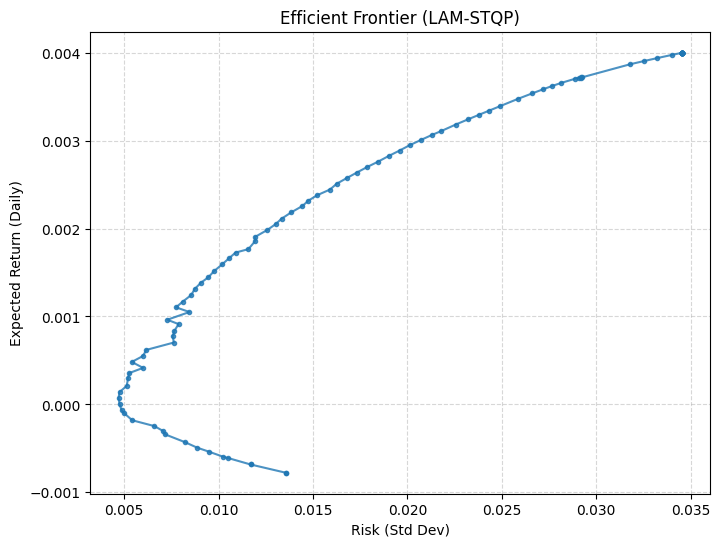

In [5]:
frontier = compute_efficient_frontier(
        mu, sigma,
        n_points=100,
        k_max=10,
        min_weight=0.01,
        max_weight=1.0,
        penalty_m=1000.0
    )

plot_efficient_frontier(frontier)

In [ ]:
frontier_df = pd.DataFrame({
    "risk": frontier["risks"],
    "return": frontier["returns"],
    "weights": [w.tolist() for w in frontier["weights"]]
})

frontier_df.to_csv("output/efficient_frontier.csv", index=False)